## Load Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pickle
import scipy as sp
import time

In [2]:
def sort_dataset_by_mean_abundance(full_dataset,family_tags,which_mean='when_present',
                                  return_argsort = False,
                                  entropies=None):
    '''
    Data is normalized into relative abundances at the end, just in case.
    '''
    means = np.mean(full_dataset,axis=0)
    above_threshold = (full_dataset>means[None,:])
    times_above_threshold = np.sum(above_threshold,axis=0)
    new_means = np.sum(full_dataset*above_threshold, #take mean only of the data where the samples are above their mean value.
                        axis=0)/times_above_threshold
    times_present = np.sum(full_dataset>0,axis=0)
    
    maxes = np.max(full_dataset,axis=0) #maximum relative abundance of each species
    ''' Sort using total mean or mean when present (new_means) '''
    if which_mean=='when_present':
        print('Sorting by mean when present')
        indices_by_mean_abundance = np.flip(np.argsort(new_means))
    elif which_mean=='maxes':
        print('Sorting by maximum value')
        indices_by_mean_abundance = np.flip(np.argsort(maxes))
    elif which_mean=='means':
        print('Sorting by mean (both present and absent)')
        indices_by_mean_abundance = np.flip(np.argsort(means))
    elif which_mean=='number_appearances':
        print('Sorting by number of appearances')
        indices_by_mean_abundance = np.flip(np.argsort(times_present))
    elif which_mean=='entropies':
        print('Sorting by entropy')
        indices_by_mean_abundance = np.flip(np.argsort(entropies))
    else:
        print('No proper sorting preference given')
    
    full_dataset = full_dataset[:,indices_by_mean_abundance]
    family_tags = [family_tags[tag] for tag in indices_by_mean_abundance]
    
    # full_dataset =full_dataset/np.sum(full_dataset,axis=1)[:,None] #renormalize back to 1 just in case, even if it should be supefluous.
    print('Most common strains: \n',family_tags[:6])
    
    how_many_experimental_samples,how_many_species = np.shape(full_dataset)

    if return_argsort ==True:
        output = (full_dataset,family_tags,how_many_experimental_samples,how_many_species,indices_by_mean_abundance)
    else:
        output = (full_dataset,family_tags,how_many_experimental_samples,how_many_species)
    return output

In [3]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.png'),format='png',dpi=200)
    plt.show()  

    return

In [4]:
def lam(a,b,L):

    Delta = (2+b*(L-1))**2-4*(1+b*(L-1)-L*a**2)
    if Delta<0:
        print(a,b,Delta)
    
    lam_plus = 0.5*(2+b*(L-1)+np.sqrt(Delta))
    lam_minus = 0.5*(2+b*(L-1)-np.sqrt(Delta))

    return lam_plus,lam_minus

def a_func(A,v,D):
    a = -np.sqrt(A*v)/(np.sqrt((D-A)*(D-v)))
    return a

def b_func(v,D):
    b = -np.sqrt(v*v)/(np.sqrt((D-v)*(D-v)))
    return b

def D_func(v,A,V,L):
    D = L*v+A+V
    return D


def large_X(b,L):
    out = 2+b*(L-1)
    return out

In [5]:
def A_from_V(r,L,v,V,s):
    ''' Explicit solution connecting V with A when s is in one of the transitions '''
    num = (L*v+V)*(1-s**2)*(s**2*(L-1)*v-(1-s**2)*V)
    den = -L*v+(1-s**2)**2*(L*v+V)
    return num/den

In [6]:
''' Select parameters according to each dataset '''
''' Estrella dataset '''

' Estrella dataset '

## Perform Data Analysis

In [6]:
dataset_name = 'Estrella_full' #displays both modes
with open('../../datasets/true_datasets/full_dataset.{}.dat'.format(dataset_name),'rb') as f:
    data = pickle.load(f)
    f.close()

with open('../../datasets/taxonomic_tags/family_tags.{}.dat'.format(dataset_name),'rb') as f:
    family_tags = pickle.load(f)
    f.close()

## For Estrella Dataset

data,family_tags,how_many_experimental_samples,how_many_species = sort_dataset_by_mean_abundance(data,
                                                                                                         family_tags,
                                                                                                        which_mean='means')
occupancy = np.sum(data>0,axis=0)/how_many_experimental_samples
data = data[:,:14]
family_tags = family_tags[:14]


''' And sort remaining species by mean abundance across datasets '''
mean_sorted_taxa = np.flip(np.argsort(np.mean(data,axis=0)))
data = data[:,mean_sorted_taxa]
family_tags = np.array(family_tags)[mean_sorted_taxa]
occupancy = occupancy[mean_sorted_taxa]


Sorting by mean (both present and absent)
Most common strains: 
 ['f.Klebsiella', 'f.Klebsiella_m', 'f.Alcaligenes', 'f.Pseudomonas', 'f.Delftia', 'f.Lachnoclostridium']


In [7]:
M,L_total = np.shape(data)

r = L_total/M


L = L_total-1 #remove the dominant taxon
vars = np.var(data,axis=0) #variance of the different species
V_data = np.var(np.sum(data,axis=1)) #variance of the total sample abundance



print(M,L)
print(V_data)

276 13
1.3609114990660077e-05


In [8]:
''' find A_data and v from the explicit form of the covariance matrix.
It's a bit involved but it essentially gives corrections to var_a and var_x '''
var_x = np.mean(vars[1:])
var_a = vars[0]
def func(v,V,L,var_a,var_x):
    ''' v as a function of Var(x),Var(a), L and V '''
    ''' Chatgpt's expression '''
    # out = (var_x-v)*(-V**2-L*v*(V+var_a))+(var_a-V-L*v)*(L*v*var_x-(L-1)*v**2)
    ''' My expression '''
    out1 = (v-var_x)
    out2 = (V+L*v+(var_a*(L*v+V))/(V+L*v-var_a))
    out = out1*out2-v**2
    return out

from scipy.optimize import fsolve

res = fsolve(func,var_x,args = (V_data,L,var_a,var_x))

v = res[0]

def A_from_v(v,V,var_a,L):
    out = var_a*(L*v+V)/(V+L*v-var_a)
    return out

A_data = A_from_v(v,V_data,var_a,L)

print(var_x,v)
print(var_a,A_data)

0.006106883346098203 0.006210205634022954
0.06327892823937964 0.2925193004271169


In [9]:
print(L,M,var_a,var_x,V_data)

13 276 0.06327892823937964 0.006106883346098203 1.3609114990660077e-05


In [10]:
print(V_data+L*var_x,var_a)

0.07940309261426728 0.06327892823937964


In [15]:
def V_asymptote_func(L,v,S):
    out = L*v*(1-(1-S**2)**2)/(1-S**2)**2
    return out

if r<1:
    S_plus = 1+np.sqrt(r)
    S_minus = 1-np.sqrt(r)
else:
    r_prima = 1/r
    S_plus =  1+np.sqrt(r_prima)
    S_minus =  1-np.sqrt(r_prima)

lam_MP_plus = S_plus**2
lam_MP_minus = S_minus**2

lower_V_asymptote = V_asymptote_func(L,v,S_plus)
higher_V_asymptote = V_asymptote_func(L,v,S_minus)

In [16]:
lam_MP_minus,lam_MP_plus

(0.6002820212197086, 1.5011672541426104)

In [17]:
A_vect = np.linspace(0,max(0.2,2*A_data),100)
V_vect = np.linspace(0.0,max(5*V_data,0.95*higher_V_asymptote),100)

In [20]:
which_options = ['Numerical','Simulated','Simulated-parallelized']
which_option = which_options[2]

### Perform simulations. Skip this.

In [22]:
from numba import njit
import multiprocessing as mp
import defs
import itertools

''' Generate random datasets with the same r as the experimental dataset, for different values of A and V,
and check whether there are significant modes in these random datasets. '''
if which_option=='Simulated-parallelized':
    time0 = time.time()
    how_many_iterations = 1000
    ''' Create a null expectation with which to compare, from an identity covariance matrix and null datasets of the same size as the true dataset '''
    null_eigvals = []
    null_eigval_inputs = [(L,M,r,v)]*how_many_iterations
    if __name__=='__main__':
            pool = mp.Pool()
            res = pool.map(defs.get_null_eigenvalues, null_eigval_inputs)
    
    null_eigvals = np.array(res).flatten()
    ''' Build the cdf of the null eigenvalues with which to compare later '''
    cdf = np.arange(1,len(null_eigvals)+1)/len(null_eigvals)
    ''' Interploate the CDF'''
    null_eigvals = np.sort(null_eigvals)
    interp_cdf = sp.interpolate.interp1d(null_eigvals,
                                        cdf,
                                        fill_value = (cdf[0],
                                                      cdf[-1]),
                                         bounds_error=False)
    significance_threshold = 1/len(null_eigvals) #which is arbitrary
    def low_eigenval(eigval):
        return interp_cdf(eigval)-significance_threshold
    def high_eigenval(eigval):
        return interp_cdf(eigval)-(1-significance_threshold)
    low_res = fsolve(low_eigenval,np.min(null_eigvals))
    lam_null_minus = low_res[0]
    high_res =  fsolve(high_eigenval,np.max(null_eigvals))
    lam_null_plus = high_res[0]
    print('lam -',lam_MP_minus,lam_null_minus)
    print('lam +',lam_MP_plus,lam_null_plus)


    with open('{}/null_eigvals.{}.{}.dat'.format(dataset_name,dataset_name,which_option),'wb') as f:
        pickle.dump((lam_null_minus,lam_null_plus),f)
        f.close()

    asdasdasd

    null_time = time.time()-time0
    print('Null model took {} seconds. Expected time per iteration: {}s.'.format(null_time,null_time*len(A_vect)*len(V_vect)/how_many_iterations))
    
    ''' Create the low-variance mode '''
    outlier_eigvect_low = np.ones(L)/np.sqrt(L)
    
    phase_matrix = np.zeros((len(A_vect),len(V_vect)))
    how_many_iterations = 100
    how_many_iterations = 2000
    
    other_args = (r,L,v,M,lam_null_minus,lam_null_plus)
    
    for it in range(how_many_iterations):
        time0 = time.time()
        

        inputs = list(itertools.product(enumerate(A_vect),enumerate(V_vect)))
        new_inputs = [(input[0],input[1],other_args) for input in inputs]
        inputs = new_inputs  

        if __name__=='__main__':
            pool = mp.Pool()
            res = pool.map(defs.check_significant_eigenvalues, inputs)
        
        for result in res:
            ii,jj,modes,eigvals = result
            phase_matrix[ii,jj] += modes

        print('Iteration: {}. Time taken: {}s'.format(it,time.time()-time0))
            
    phase_matrix = phase_matrix/how_many_iterations
    with open('{}/phase_matrix.{}.{}.dat'.format(dataset_name,dataset_name,which_option),'wb') as f:
        pickle.dump(phase_matrix,f)
        f.close()
else:
    print('You chose the simulated solution of the equations, but your option is set to {}'.format(which_option))


        
        

lam_MP 0.6002820212197086 0.545387376229745
lam_numerical_null 1.5011672541426104 1.6241997673394695


NameError: name 'asdasdasd' is not defined

### Continue

In [22]:
''' Load Phase Matrix if pre-computed '''
with open('{}/phase_matrix.{}.{}.dat'.format(dataset_name,dataset_name,which_option),'rb') as f:
        phase_matrix = pickle.load(f)
        f.close()

with open('{}/null_eigvals.{}.{}.dat'.format(dataset_name,dataset_name,which_option),'rb') as f:
        (lam_null_minus,lam_null_plus) = pickle.load(f)
        f.close()

A+(V=0) 0.07487122842943524
A_data 0.2925193004271169


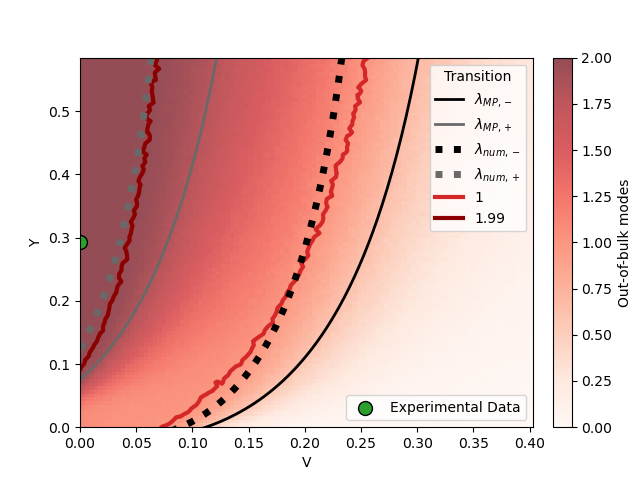

In [23]:
%matplotlib widget
plt.close('all')
fig,ax = plt.subplots()
threshold = None
if threshold == None:
    im = ax.imshow(phase_matrix,cmap='Reds',
              origin= 'lower',alpha=0.7,
              extent = (V_vect[0],V_vect[-1],
                        A_vect[0],A_vect[-1]),
              aspect='auto',
              vmin = 0 ,vmax= 2
             )
    fig.colorbar(im,label='Out-of-bulk modes',ax=ax, fraction=0.046, pad=0.04)
elif threshold == True:
    plot_phase_matrix = phase_matrix//0.99
    im = ax.imshow(plot_phase_matrix,cmap='Reds',
              origin= 'lower',alpha=0.7,
              extent = (V_vect[0],V_vect[-1],
                        A_vect[0],A_vect[-1]),
              aspect='auto',
              vmin = 0 ,vmax= 2
             )
    fig.colorbar(im,label='Out-of-bulk modes',ax=ax, fraction=0.046, pad=0.04)
else:
    im = ax.imshow(phase_matrix>threshold,cmap='Reds',
              origin= 'lower',alpha=0.7,
              extent = (V_vect[0],V_vect[-1],
                        A_vect[0],A_vect[-1]),
              aspect='auto',
              vmin = 0 ,vmax= 2
             )
    fig.colorbar(im,label='Out-of-bulk modes',ax=ax, fraction=0.046, pad=0.04)

V_vect_high_reduced = np.linspace(0,0.98*higher_V_asymptote,100)
ax.plot(V_vect_high_reduced,
        A_from_V(r,L,v,V_vect_high_reduced,S_minus),
        color='k',linestyle='-',
       linewidth=2,label=r'$\lambda_{MP,-}$' )
ax.set_ylim(bottom=A_vect[0],top=A_vect[-1])

V_vect_low_reduced = np.linspace(0,0.98*lower_V_asymptote,100)
ax.plot(V_vect_low_reduced,
        A_from_V(r,L,v,V_vect_low_reduced,S_plus),
        color='dimgray',linestyle='-',
       linewidth=2,label=r'$\lambda_{MP,+}$')

if which_option =='Simulated' or which_option == 'Simulated-parallelized':
    ''' Plot also the expected transition lines, from theory, but for the limit eigenvalues built from the null model, not the MP theory '''
    
    S_minus_null =np.sqrt(lam_null_minus)
    higher_V_asymptote_null = V_asymptote_func(L,v,S_minus_null)
    V_vect_high_reduced = np.linspace(0,0.98*higher_V_asymptote_null,100)
    ax.plot(V_vect_high_reduced,
            A_from_V(r,L,v,V_vect_high_reduced,S_minus_null),
            color='k',linestyle=':',
           linewidth=5,label=r'$\lambda_{num,-}$' ) #might want to change for lambda_{num.,...}
    ax.set_ylim(bottom=A_vect[0],top=A_vect[-1])
    
    
    S_plus_null = np.sqrt(lam_null_plus)
    lower_V_asymptote_null = V_asymptote_func(L,v,S_plus_null)
    V_vect_low_reduced = np.linspace(0,0.98*lower_V_asymptote_null,100)
    ax.plot(V_vect_low_reduced,
            A_from_V(r,L,v,V_vect_low_reduced,S_plus_null),
            color='dimgray',linestyle=':',
           linewidth=5,label=r'$\lambda_{num,+}$')


from skimage import measure
z0= 1.0
contours = np.array(measure.find_contours(phase_matrix,level=z0))[0]
x = contours[:,0]; y = contours[:,1]
x_plot = np.interp(y,np.arange(len(V_vect)),V_vect)
y_plot = np.interp(x,np.arange(len(A_vect)),A_vect)
plt.plot(x_plot,y_plot,'tab:red',linewidth=3,label='1',zorder=1)

z0= 1.98
contours = np.array(measure.find_contours(phase_matrix,level=z0))[0]
x = contours[:,0]; y = contours[:,1]
x_plot = np.interp(y,np.arange(len(V_vect)),V_vect)
y_plot = np.interp(x,np.arange(len(A_vect)),A_vect)
plt.plot(x_plot,y_plot,'darkred',linewidth=3,label='1.99',zorder=1)


first_legend  = ax.legend(title='Transition',
          loc='upper right',
          frameon=True)
ax.add_artist(first_legend)
ax.set_xlabel('V')
ax.set_ylabel('Y')






experimental_point = ax.scatter(V_data,A_data,edgecolor='k',s=100,c='tab:green',
                                label='Experimental Data' if dataset_name=='Estrella_full' else dataset_name)
ax.legend(handles=[experimental_point], loc='lower right',frameon=True)


ax.set_xlim(left=V_vect[0],right=np.max((V_vect[-1],V_data*1.1)))
print('A+(V=0)',A_from_V(r,L,v,0,S_plus))
print('A_data',A_data)

if threshold==None:
    plt.savefig('{}/phase_map.{}.png'.format(dataset_name,which_option),format='png',dpi=300,transparent=True)
    plt.savefig('{}/phase_map.{}.pdf'.format(dataset_name,which_option),format='pdf',transparent=True)
else:
    plt.savefig('{}/phase_map.{}.thres.{}.png'.format(dataset_name,which_option,threshold),format='png',transparent=True)
    plt.savefig('{}/phase_map.{}.thres.{}.pdf'.format(dataset_name,which_option,threshold),format='pdf',transparent=True)